In [11]:
import os

print(os.getcwd())

C:\Users\DELL


In [13]:
import glob

glob.glob("*.csv")

['Indian FMCG Retail Sales  Customer  Inventory (2024).csv',
 'monthly_sales_results.csv',
 'Sample - Superstore.csv',
 'sql_monthly_sales_results.csv',
 'top_3_months.csv']

In [17]:
import pandas as pd
import glob

# Find the FMCG CSV file
csv_file = glob.glob("*FMCG*.csv")[0]

print("File found:", csv_file)

File found: Indian FMCG Retail Sales  Customer  Inventory (2024).csv


In [19]:
df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [21]:
df.head()

,Invoice_ID,Invoice_Date,City,Store_Format,Category,Brand,Channel,Payment_Mode,Units,Cost_Price,...,Revenue,Cost,Margin,Margin_%,Stock_On_Hand,Reorder_Level,Lead_Time_Days,Customer_Age,Customer_Gender,Loyalty_Flag
0,58018430,2024-02-02 13:50:00,Kolkata,Super,Grocery,Nestle,Online,Wallet,2,148.999035,...,350.114418,297.998070,52.116348,0.148855,154,31,11,20.0,M,1
1,48157952,2024-10-09 11:52:00,Hyderabad,Hyper,Home Care,PepsiCo,Offline,Wallet,1,80.626759,...,106.034197,80.626759,25.407438,0.239616,130,24,5,26.0,F,1
2,23283831,2024-08-26 22:03:00,Chennai,Hyper,Snacks,PepsiCo,Online,Card,5,181.233170,...,1044.900114,906.165848,138.734266,0.132773,270,44,8,27.0,F,0
3,53537460,2024-06-09 04:34:00,Bengaluru,Hyper,Beverages,Nestle,Omnichannel,Card,2,195.811402,...,521.759920,391.622805,130.137115,0.249420,403,63,8,NaN,F,0
4,55348596,2024-06-07 01:13:00,Delhi,Super,Snacks,ITC,Offline,Card,3,23.571888,...,91.873416,70.715665,21.157751,0.230292,366,40,9,60.0,F,1


In [23]:
df.shape

(100000, 21)

In [25]:
df.columns.tolist()

['Invoice_ID',
 'Invoice_Date',
 'City',
 'Store_Format',
 'Category',
 'Brand',
 'Channel',
 'Payment_Mode',
 'Units',
 'Cost_Price',
 'Selling_Price',
 'Revenue',
 'Cost',
 'Margin',
 'Margin_%',
 'Stock_On_Hand',
 'Reorder_Level',
 'Lead_Time_Days',
 'Customer_Age',
 'Customer_Gender',
 'Loyalty_Flag']

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Invoice_ID       100000 non-null  int64  
 1   Invoice_Date     100000 non-null  object 
 2   City             100000 non-null  object 
 3   Store_Format     100000 non-null  object 
 4   Category         100000 non-null  object 
 5   Brand            100000 non-null  object 
 6   Channel          100000 non-null  object 
 7   Payment_Mode     100000 non-null  object 
 8   Units            100000 non-null  int64  
 9   Cost_Price       100000 non-null  float64
 10  Selling_Price    100000 non-null  float64
 11  Revenue          100000 non-null  float64
 12  Cost             100000 non-null  float64
 13  Margin           100000 non-null  float64
 14  Margin_%         100000 non-null  float64
 15  Stock_On_Hand    100000 non-null  int64  
 16  Reorder_Level    100000 non-null  int64

In [29]:
df.isnull().sum()

Invoice_ID             0
Invoice_Date           0
City                   0
Store_Format           0
Category               0
Brand                  0
Channel                0
Payment_Mode           0
Units                  0
Cost_Price             0
Selling_Price          0
Revenue                0
Cost                   0
Margin                 0
Margin_%               0
Stock_On_Hand          0
Reorder_Level          0
Lead_Time_Days         0
Customer_Age       40081
Customer_Gender     5048
Loyalty_Flag           0
dtype: int64

In [31]:
df.duplicated().sum()

0

In [33]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Customer_Age       40081
Customer_Gender     5048
dtype: int64

In [35]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [37]:
print("Negative Units:", (df["Units"] < 0).sum())

print("Negative Revenue:", (df["Revenue"] < 0).sum())

print("Negative Cost:", (df["Cost"] < 0).sum())

print("Negative Stock:", (df["Stock_On_Hand"] < 0).sum())

Negative Units: 0
Negative Revenue: 0
Negative Cost: 0
Negative Stock: 0


In [39]:
calculated_margin = df["Revenue"] - df["Cost"]

difference = (df["Margin"] - calculated_margin).abs()

print("Maximum Margin Difference:", difference.max())

Maximum Margin Difference: 3.979039320256561e-13


In [41]:
quality_summary = pd.DataFrame({
    "Missing_Values": df.isnull().sum(),
    "Data_Type": df.dtypes.astype(str),
    "Unique_Values": df.nunique()
})

quality_summary

,Missing_Values,Data_Type,Unique_Values
Invoice_ID,0,int64,99938
Invoice_Date,0,object,91057
City,0,object,8
Store_Format,0,object,3
Category,0,object,8
Brand,0,object,8
Channel,0,object,3
Payment_Mode,0,object,4
Units,0,int64,5
Cost_Price,0,float64,100000


In [43]:
clean_df = df.copy()

In [45]:
clean_df["Invoice_Date"] = pd.to_datetime(
    clean_df["Invoice_Date"],
    errors="coerce"
)

In [47]:
clean_df["Customer_Gender"] = clean_df["Customer_Gender"].fillna("Unknown")

print("Missing Gender Values:",
      clean_df["Customer_Gender"].isnull().sum())

Missing Gender Values: 0


In [49]:
print("Missing Age Values:",
      clean_df["Customer_Age"].isnull().sum())

Missing Age Values: 40081


In [51]:
print("Invalid Dates:",
      clean_df["Invoice_Date"].isnull().sum())

Invalid Dates: 0


In [53]:
# Overall Business Performance

total_revenue = clean_df["Revenue"].sum()
total_cost = clean_df["Cost"].sum()
total_profit = clean_df["Margin"].sum()
total_units = clean_df["Units"].sum()

profit_margin = (total_profit / total_revenue) * 100

print("Total Revenue:", round(total_revenue, 2))
print("Total Cost:", round(total_cost, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Units Sold:", total_units)
print("Overall Profit Margin:", round(profit_margin, 2), "%")

Total Revenue: 39335134.98
Total Cost: 31461449.33
Total Profit: 7873685.66
Total Units Sold: 299829
Overall Profit Margin: 20.02 %


In [55]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Cost",
        "Total Profit",
        "Total Units Sold",
        "Profit Margin (%)"
    ],
    "Value": [
        total_revenue,
        total_cost,
        total_profit,
        total_units,
        profit_margin
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,3.933513e+07
1,Total Cost,3.146145e+07
2,Total Profit,7.873686e+06
3,Total Units Sold,2.998290e+05
4,Profit Margin (%),2.001693e+01


In [57]:
clean_df.columns.tolist()

['Invoice_ID',
 'Invoice_Date',
 'City',
 'Store_Format',
 'Category',
 'Brand',
 'Channel',
 'Payment_Mode',
 'Units',
 'Cost_Price',
 'Selling_Price',
 'Revenue',
 'Cost',
 'Margin',
 'Margin_%',
 'Stock_On_Hand',
 'Reorder_Level',
 'Lead_Time_Days',
 'Customer_Age',
 'Customer_Gender',
 'Loyalty_Flag']

In [59]:
category_analysis = clean_df.groupby("Category").agg(
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
    Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

category_analysis

,Category,Revenue,Cost,Profit,Units_Sold
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381


In [61]:
category_analysis.sort_values(
    by="Profit",
    ascending=False
)

,Category,Revenue,Cost,Profit,Units_Sold
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770


In [63]:
clean_df.columns.tolist()

['Invoice_ID',
 'Invoice_Date',
 'City',
 'Store_Format',
 'Category',
 'Brand',
 'Channel',
 'Payment_Mode',
 'Units',
 'Cost_Price',
 'Selling_Price',
 'Revenue',
 'Cost',
 'Margin',
 'Margin_%',
 'Stock_On_Hand',
 'Reorder_Level',
 'Lead_Time_Days',
 'Customer_Age',
 'Customer_Gender',
 'Loyalty_Flag']

In [65]:
categorical_columns = clean_df.select_dtypes(
    include="object"
).columns

print(categorical_columns.tolist())

['City', 'Store_Format', 'Category', 'Brand', 'Channel', 'Payment_Mode', 'Customer_Gender']


In [69]:
clean_df["Category"].unique()

array(['Grocery', 'Home Care', 'Snacks', 'Beverages', 'Dairy',
       'Personal Care', 'Vegetables', 'Fruits'], dtype=object)

In [71]:
category_analysis = clean_df.groupby("Category").agg(
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
    Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

category_analysis

,Category,Revenue,Cost,Profit,Units_Sold
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381


In [73]:
category_analysis["Profit_Margin_%"] = (
    category_analysis["Profit"] /
    category_analysis["Revenue"] * 100
)

category_analysis

,Category,Revenue,Cost,Profit,Units_Sold,Profit_Margin_%
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863,19.899459
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770,20.022608
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195,19.924854
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400,20.144767
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790,19.920707
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012,20.097242
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418,20.072863
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381,20.054679


In [75]:
category_analysis.sort_values(
    by="Revenue",
    ascending=False
)

,Category,Revenue,Cost,Profit,Units_Sold,Profit_Margin_%
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195,19.924854
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400,20.144767
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418,20.072863
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863,19.899459
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790,19.920707
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381,20.054679
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012,20.097242
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770,20.022608


In [77]:
import matplotlib.pyplot as plt

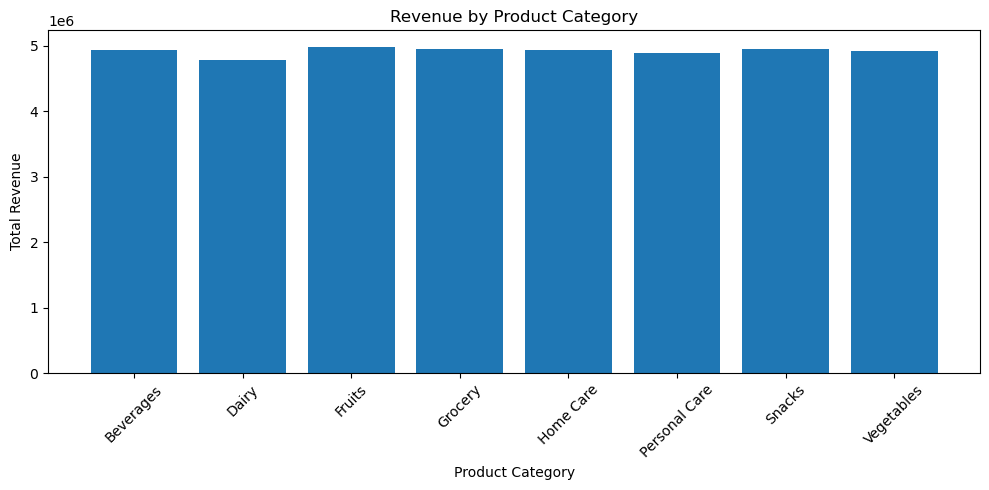

In [79]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_analysis["Category"],
    category_analysis["Revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

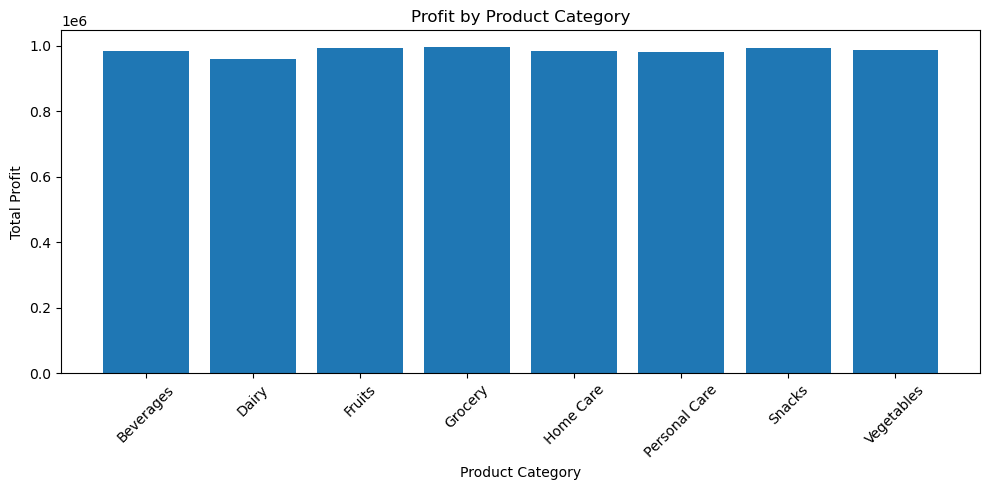

In [81]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_analysis["Category"],
    category_analysis["Profit"]
)

plt.title("Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

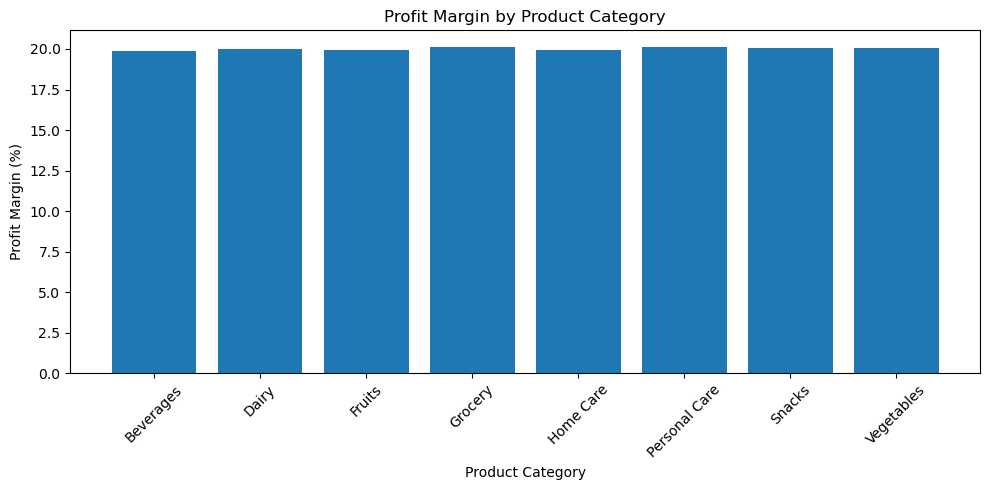

In [83]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_analysis["Category"],
    category_analysis["Profit_Margin_%"]
)

plt.title("Profit Margin by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit Margin (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
city_analysis = clean_df.groupby("City").agg(
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
    Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

city_analysis

,City,Revenue,Cost,Profit,Units_Sold
0,Ahmedabad,4.877775e+06,3.906318e+06,971456.681198,37209
1,Bengaluru,4.824230e+06,3.861446e+06,962784.440103,37233
2,Chennai,4.900659e+06,3.917686e+06,982972.844229,37533
3,Delhi,4.985262e+06,3.988230e+06,997031.982294,37946
4,Hyderabad,4.950787e+06,3.961237e+06,989549.918248,37568
5,Kolkata,4.999465e+06,4.000836e+06,998628.701894,38049
6,Mumbai,4.897600e+06,3.913456e+06,984144.670001,37273
7,Pune,4.899357e+06,3.912240e+06,987116.417330,37018


In [87]:
city_analysis["Profit_Margin_%"] = (
    city_analysis["Profit"] /
    city_analysis["Revenue"] * 100
)

city_analysis

,City,Revenue,Cost,Profit,Units_Sold,Profit_Margin_%
0,Ahmedabad,4.877775e+06,3.906318e+06,971456.681198,37209,19.915981
1,Bengaluru,4.824230e+06,3.861446e+06,962784.440103,37233,19.957266
2,Chennai,4.900659e+06,3.917686e+06,982972.844229,37533,20.057972
3,Delhi,4.985262e+06,3.988230e+06,997031.982294,37946,19.999590
4,Hyderabad,4.950787e+06,3.961237e+06,989549.918248,37568,19.987730
5,Kolkata,4.999465e+06,4.000836e+06,998628.701894,38049,19.974711
6,Mumbai,4.897600e+06,3.913456e+06,984144.670001,37273,20.094427
7,Pune,4.899357e+06,3.912240e+06,987116.417330,37018,20.147878


In [89]:
top_cities_revenue = city_analysis.sort_values(
    by="Revenue",
    ascending=False
).head(10)

top_cities_revenue

,City,Revenue,Cost,Profit,Units_Sold,Profit_Margin_%
5,Kolkata,4.999465e+06,4.000836e+06,998628.701894,38049,19.974711
3,Delhi,4.985262e+06,3.988230e+06,997031.982294,37946,19.999590
4,Hyderabad,4.950787e+06,3.961237e+06,989549.918248,37568,19.987730
2,Chennai,4.900659e+06,3.917686e+06,982972.844229,37533,20.057972
7,Pune,4.899357e+06,3.912240e+06,987116.417330,37018,20.147878
6,Mumbai,4.897600e+06,3.913456e+06,984144.670001,37273,20.094427
0,Ahmedabad,4.877775e+06,3.906318e+06,971456.681198,37209,19.915981
1,Bengaluru,4.824230e+06,3.861446e+06,962784.440103,37233,19.957266


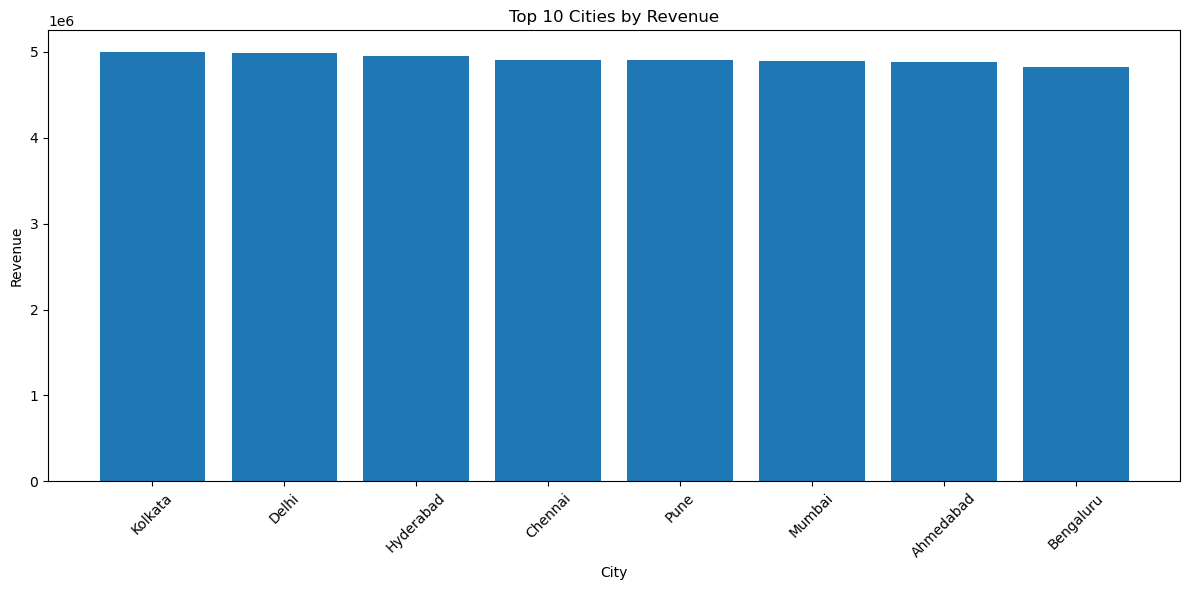

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    top_cities_revenue["City"],
    top_cities_revenue["Revenue"]
)

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [93]:
top_cities_profit = city_analysis.sort_values(
    by="Profit",
    ascending=False
).head(10)

top_cities_profit

,City,Revenue,Cost,Profit,Units_Sold,Profit_Margin_%
5,Kolkata,4.999465e+06,4.000836e+06,998628.701894,38049,19.974711
3,Delhi,4.985262e+06,3.988230e+06,997031.982294,37946,19.999590
4,Hyderabad,4.950787e+06,3.961237e+06,989549.918248,37568,19.987730
7,Pune,4.899357e+06,3.912240e+06,987116.417330,37018,20.147878
6,Mumbai,4.897600e+06,3.913456e+06,984144.670001,37273,20.094427
2,Chennai,4.900659e+06,3.917686e+06,982972.844229,37533,20.057972
0,Ahmedabad,4.877775e+06,3.906318e+06,971456.681198,37209,19.915981
1,Bengaluru,4.824230e+06,3.861446e+06,962784.440103,37233,19.957266


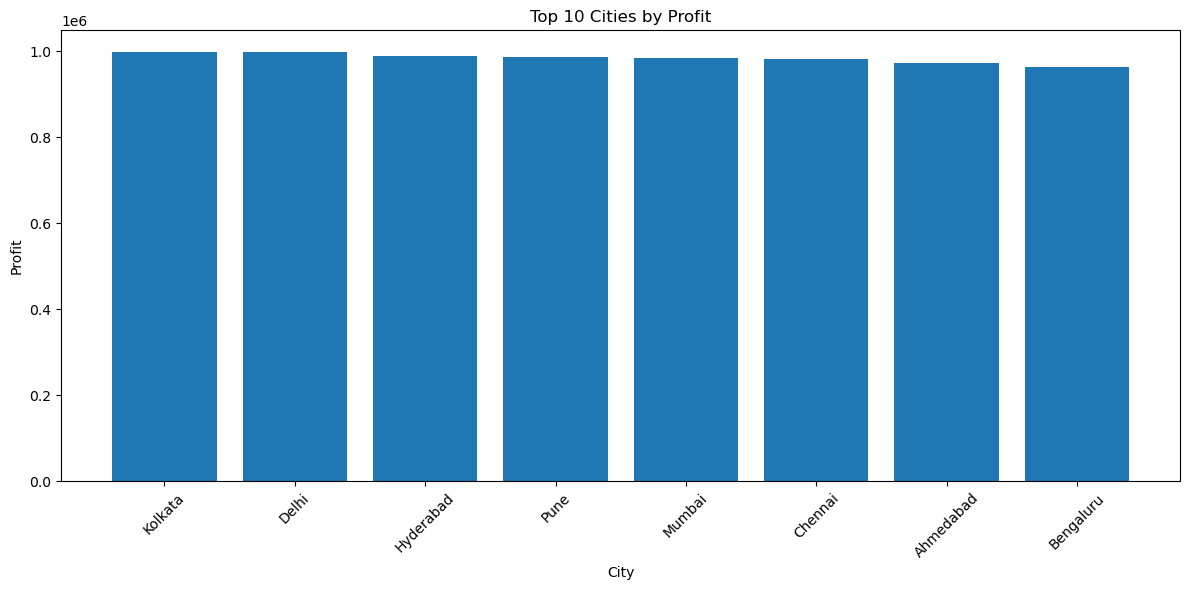

In [95]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_cities_profit["City"],
    top_cities_profit["Profit"]
)

plt.title("Top 10 Cities by Profit")
plt.xlabel("City")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [97]:
clean_df["Year_Month"] = clean_df["Invoice_Date"].dt.to_period("M")

In [99]:
monthly_analysis = clean_df.groupby("Year_Month").agg(
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
    Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

monthly_analysis

,Year_Month,Revenue,Cost,Profit,Units_Sold
0,2024-01,3.365381e+06,2.692882e+06,672498.066820,25706
1,2024-02,3.140896e+06,2.506310e+06,634585.875954,23686
2,2024-03,3.350248e+06,2.682046e+06,668202.083930,25489
3,2024-04,3.280836e+06,2.624363e+06,656472.528733,24884
4,2024-05,3.346824e+06,2.671665e+06,675158.983026,25329
5,2024-06,3.175118e+06,2.537376e+06,637742.152026,24171
6,2024-07,3.346063e+06,2.678745e+06,667318.030477,25449
7,2024-08,3.375015e+06,2.696940e+06,678074.927123,25521
8,2024-09,3.211408e+06,2.573866e+06,637541.285384,24868
9,2024-10,3.330184e+06,2.666225e+06,663959.481059,25617


In [101]:
monthly_analysis["Profit_Margin_%"] = (
    monthly_analysis["Profit"] /
    monthly_analysis["Revenue"] * 100
)

monthly_analysis

,Year_Month,Revenue,Cost,Profit,Units_Sold,Profit_Margin_%
0,2024-01,3.365381e+06,2.692882e+06,672498.066820,25706,19.982824
1,2024-02,3.140896e+06,2.506310e+06,634585.875954,23686,20.203975
2,2024-03,3.350248e+06,2.682046e+06,668202.083930,25489,19.944854
3,2024-04,3.280836e+06,2.624363e+06,656472.528733,24884,20.009307
4,2024-05,3.346824e+06,2.671665e+06,675158.983026,25329,20.173124
5,2024-06,3.175118e+06,2.537376e+06,637742.152026,24171,20.085621
6,2024-07,3.346063e+06,2.678745e+06,667318.030477,25449,19.943377
7,2024-08,3.375015e+06,2.696940e+06,678074.927123,25521,20.091019
8,2024-09,3.211408e+06,2.573866e+06,637541.285384,24868,19.852394
9,2024-10,3.330184e+06,2.666225e+06,663959.481059,25617,19.937620


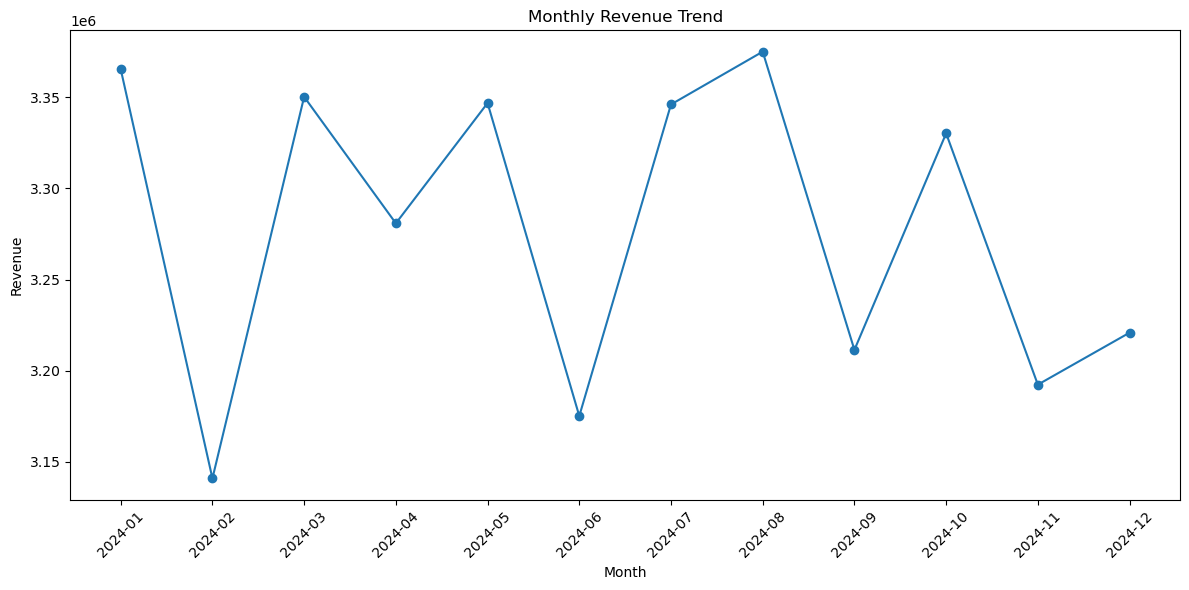

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis["Year_Month"].astype(str),
    monthly_analysis["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

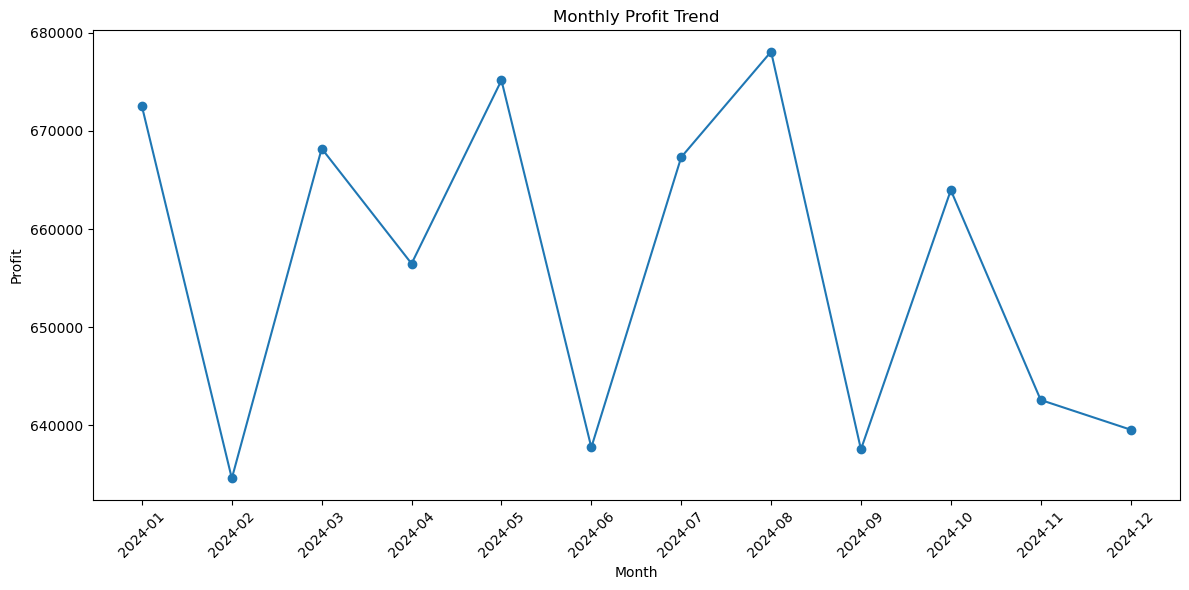

In [105]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis["Year_Month"].astype(str),
    monthly_analysis["Profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [107]:
store_analysis = clean_df.groupby("Store_Format").agg(
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
    Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

store_analysis["Profit_Margin_%"] = (
    store_analysis["Profit"] /
    store_analysis["Revenue"] * 100
)

store_analysis

,Store_Format,Revenue,Cost,Profit,Units_Sold,Profit_Margin_%
0,Express,1.300991e+07,1.040686e+07,2.603055e+06,99897,20.008240
1,Hyper,1.322563e+07,1.058109e+07,2.644536e+06,100671,19.995543
2,Super,1.309959e+07,1.047350e+07,2.626095e+06,99261,20.047146


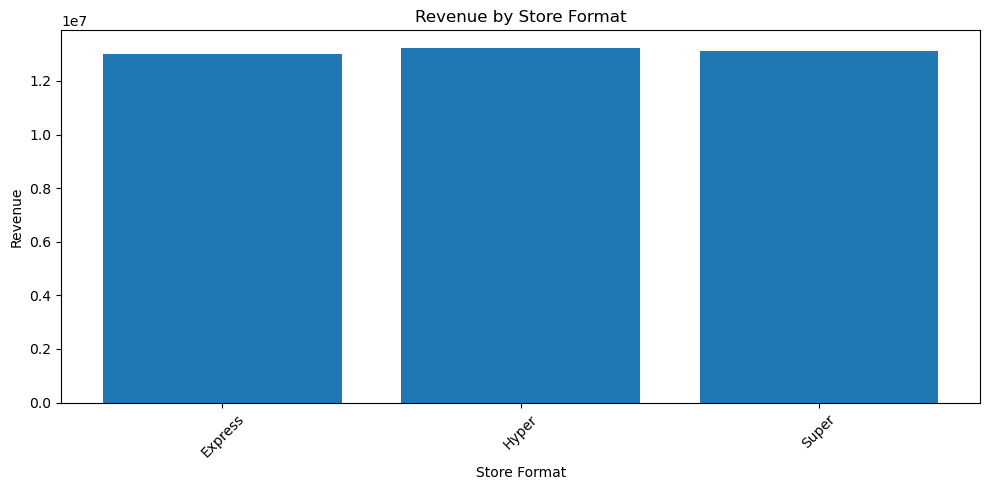

In [109]:
plt.figure(figsize=(10, 5))

plt.bar(
    store_analysis["Store_Format"],
    store_analysis["Revenue"]
)

plt.title("Revenue by Store Format")
plt.xlabel("Store Format")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [111]:
channel_analysis = clean_df.groupby("Channel").agg(
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
    Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

channel_analysis["Profit_Margin_%"] = (
    channel_analysis["Profit"] /
    channel_analysis["Revenue"] * 100
)

channel_analysis

,Channel,Revenue,Cost,Profit,Units_Sold,Profit_Margin_%
0,Offline,1.305448e+07,1.044516e+07,2.609320e+06,99698,19.987919
1,Omnichannel,1.316299e+07,1.052513e+07,2.637861e+06,100280,20.039982
2,Online,1.311766e+07,1.049115e+07,2.626505e+06,99851,20.022664


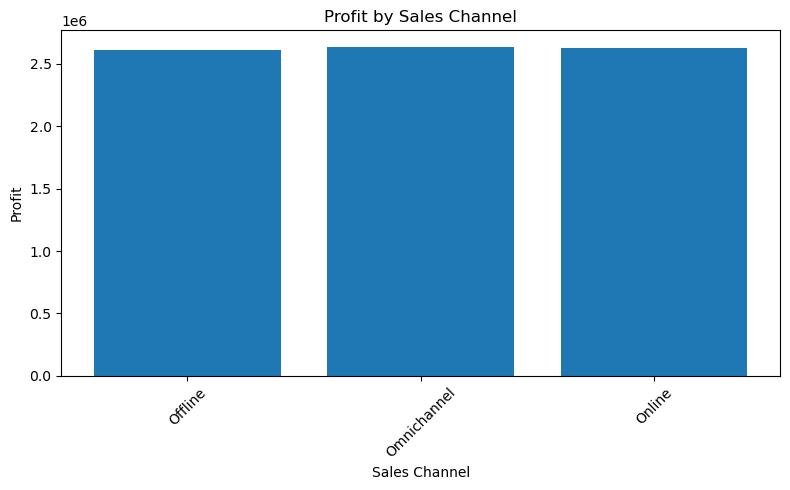

In [113]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_analysis["Channel"],
    channel_analysis["Profit"]
)

plt.title("Profit by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [115]:
payment_analysis = clean_df.groupby("Payment_Mode").agg(
    Revenue=("Revenue", "sum"),
    Transactions=("Payment_Mode", "count"),
    Profit=("Margin", "sum")
).reset_index()

payment_analysis

,Payment_Mode,Revenue,Transactions,Profit
0,Card,9.857941e+06,25127,1.973361e+06
1,Cash,9.742697e+06,24749,1.951234e+06
2,UPI,9.906216e+06,25236,1.983468e+06
3,Wallet,9.828282e+06,24888,1.965623e+06


In [117]:
clean_df[
    ["Category", "Brand", "Stock_On_Hand", "Reorder_Level", "Lead_Time_Days"]
].head()

,Category,Brand,Stock_On_Hand,Reorder_Level,Lead_Time_Days
0,Grocery,Nestle,154,31,11
1,Home Care,PepsiCo,130,24,5
2,Snacks,PepsiCo,270,44,8
3,Beverages,Nestle,403,63,8
4,Snacks,ITC,366,40,9


In [119]:
clean_df["Low_Stock_Flag"] = (
    clean_df["Stock_On_Hand"] <= clean_df["Reorder_Level"]
)

In [121]:
clean_df["Low_Stock_Flag"].value_counts()

Low_Stock_Flag
False    98271
True      1729
Name: count, dtype: int64

In [123]:
inventory_analysis = clean_df.groupby("Category").agg(
    Average_Stock=("Stock_On_Hand", "mean"),
    Average_Reorder_Level=("Reorder_Level", "mean"),
    Average_Lead_Time=("Lead_Time_Days", "mean"),
    Revenue=("Revenue", "sum"),
    Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

inventory_analysis

,Category,Average_Stock,Average_Reorder_Level,Average_Lead_Time,Revenue,Profit,Units_Sold
0,Beverages,274.397775,49.387922,8.541041,4.941030e+06,983238.273218,37863
1,Dairy,274.192013,49.457539,8.549307,4.787859e+06,958654.274803,36770
2,Fruits,274.329792,49.428470,8.500000,4.985418e+06,993337.256857,38195
3,Grocery,273.460683,49.729617,8.507976,4.947363e+06,996634.794798,37400
4,Home Care,274.317340,49.361045,8.466904,4.931420e+06,982373.840734,37790
5,Personal Care,275.142477,49.450399,8.519381,4.884187e+06,981586.979222,37012
6,Snacks,273.907144,49.567764,8.540275,4.942555e+06,992112.232178,37418
7,Vegetables,273.501684,49.362412,8.510744,4.915302e+06,985748.003486,37381


In [125]:
inventory_analysis["Stock_Risk"] = (
    inventory_analysis["Average_Stock"] <=
    inventory_analysis["Average_Reorder_Level"]
)

inventory_analysis

,Category,Average_Stock,Average_Reorder_Level,Average_Lead_Time,Revenue,Profit,Units_Sold,Stock_Risk
0,Beverages,274.397775,49.387922,8.541041,4.941030e+06,983238.273218,37863,False
1,Dairy,274.192013,49.457539,8.549307,4.787859e+06,958654.274803,36770,False
2,Fruits,274.329792,49.428470,8.500000,4.985418e+06,993337.256857,38195,False
3,Grocery,273.460683,49.729617,8.507976,4.947363e+06,996634.794798,37400,False
4,Home Care,274.317340,49.361045,8.466904,4.931420e+06,982373.840734,37790,False
5,Personal Care,275.142477,49.450399,8.519381,4.884187e+06,981586.979222,37012,False
6,Snacks,273.907144,49.567764,8.540275,4.942555e+06,992112.232178,37418,False
7,Vegetables,273.501684,49.362412,8.510744,4.915302e+06,985748.003486,37381,False


In [127]:
lead_time_analysis = clean_df.groupby("Category").agg(
    Average_Lead_Time=("Lead_Time_Days", "mean"),
    Total_Profit=("Margin", "sum"),
    Total_Revenue=("Revenue", "sum")
).reset_index()

lead_time_analysis.sort_values(
    by="Average_Lead_Time",
    ascending=False
)

,Category,Average_Lead_Time,Total_Profit,Total_Revenue
1,Dairy,8.549307,958654.274803,4.787859e+06
0,Beverages,8.541041,983238.273218,4.941030e+06
6,Snacks,8.540275,992112.232178,4.942555e+06
5,Personal Care,8.519381,981586.979222,4.884187e+06
7,Vegetables,8.510744,985748.003486,4.915302e+06
3,Grocery,8.507976,996634.794798,4.947363e+06
2,Fruits,8.500000,993337.256857,4.985418e+06
4,Home Care,8.466904,982373.840734,4.931420e+06


In [129]:
clean_df.columns.tolist()

['Invoice_ID',
 'Invoice_Date',
 'City',
 'Store_Format',
 'Category',
 'Brand',
 'Channel',
 'Payment_Mode',
 'Units',
 'Cost_Price',
 'Selling_Price',
 'Revenue',
 'Cost',
 'Margin',
 'Margin_%',
 'Stock_On_Hand',
 'Reorder_Level',
 'Lead_Time_Days',
 'Customer_Age',
 'Customer_Gender',
 'Loyalty_Flag',
 'Year_Month',
 'Low_Stock_Flag']

In [131]:
discount_columns = [
    col for col in clean_df.columns
    if "discount" in col.lower()
]

discount_columns

[]

In [135]:
category_profit = clean_df.groupby("Category").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

category_profit

,Category,Total_Revenue,Total_Cost,Total_Profit,Units_Sold
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381


In [137]:
category_profit["Profit_Margin_%"] = (
    category_profit["Total_Profit"] /
    category_profit["Total_Revenue"]
) * 100

category_profit.sort_values(
    by="Total_Profit",
    ascending=True
)

,Category,Total_Revenue,Total_Cost,Total_Profit,Units_Sold,Profit_Margin_%
1,Dairy,4.787859e+06,3.829205e+06,958654.274803,36770,20.022608
5,Personal Care,4.884187e+06,3.902600e+06,981586.979222,37012,20.097242
4,Home Care,4.931420e+06,3.949047e+06,982373.840734,37790,19.920707
0,Beverages,4.941030e+06,3.957792e+06,983238.273218,37863,19.899459
7,Vegetables,4.915302e+06,3.929554e+06,985748.003486,37381,20.054679
6,Snacks,4.942555e+06,3.950442e+06,992112.232178,37418,20.072863
2,Fruits,4.985418e+06,3.992081e+06,993337.256857,38195,19.924854
3,Grocery,4.947363e+06,3.950728e+06,996634.794798,37400,20.144767


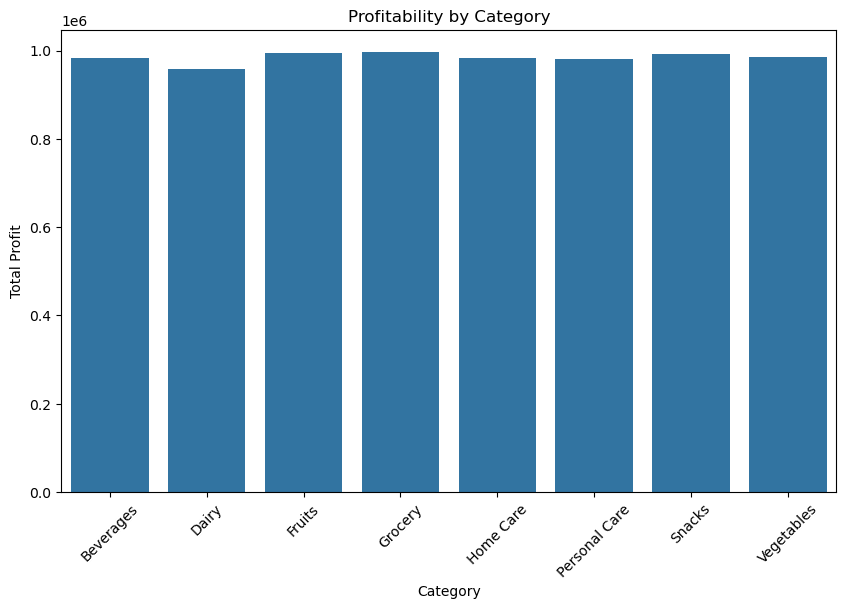

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_profit,
    x="Category",
    y="Total_Profit"
)

plt.title("Profitability by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

In [141]:
brand_profit = clean_df.groupby("Brand").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()
brand_profit = clean_df.groupby("Brand").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

brand_profit["Profit_Margin_%"] = (
    brand_profit["Total_Profit"] /
    brand_profit["Total_Revenue"]
) * 100

brand_profit.sort_values(
    by="Total_Profit",
    ascending=True
)
brand_profit["Profit_Margin_%"] = (
    brand_profit["Total_Profit"] /
    brand_profit["Total_Revenue"]
) * 100

brand_profit.sort_values(
    by="Total_Profit",
    ascending=True
)

,Brand,Total_Revenue,Total_Cost,Total_Profit,Units_Sold,Profit_Margin_%
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,20.034549
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,19.918014
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,20.039830
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,19.871711
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,20.057843
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,19.998571
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,20.183960
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,20.030033


In [143]:
least_profitable_brands = brand_profit.sort_values(
    by="Total_Profit",
    ascending=True
).head(10)

least_profitable_brands

,Brand,Total_Revenue,Total_Cost,Total_Profit,Units_Sold,Profit_Margin_%
5,Parle,4.804785e+06,3.842168e+06,9.626169e+05,36707,20.034549
6,PepsiCo,4.853370e+06,3.886675e+06,9.666948e+05,37205,19.918014
7,Tata,4.868136e+06,3.892570e+06,9.755662e+05,37331,20.039830
1,Britannia,4.942030e+06,3.959964e+06,9.820660e+05,37602,19.871711
4,Nestle,4.941904e+06,3.950665e+06,9.912394e+05,37559,20.057843
2,HUL,4.967523e+06,3.974090e+06,9.934337e+05,37745,19.998571
0,Amul,4.937874e+06,3.941216e+06,9.966585e+05,37597,20.183960
3,ITC,5.019513e+06,4.014103e+06,1.005410e+06,38083,20.030033


In [4]:
import pandas as pd
import glob

csv_file = glob.glob("*FMCG*.csv")[0]

df = pd.read_csv(csv_file)
clean_df = df.copy()

clean_df["Invoice_Date"] = pd.to_datetime(
    clean_df["Invoice_Date"],
    errors="coerce"
)

clean_df["Customer_Gender"] = clean_df["Customer_Gender"].fillna("Unknown")

clean_df["Year_Month"] = clean_df["Invoice_Date"].dt.to_period("M").astype(str)

print("Data loaded successfully!")
print(clean_df.shape)

Data loaded successfully!
(100000, 22)


In [6]:
monthly_sales = clean_df.groupby("Year_Month").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

monthly_sales

,Year_Month,Total_Revenue,Total_Profit,Units_Sold
0,2024-01,3.365381e+06,672498.066820,25706
1,2024-02,3.140896e+06,634585.875954,23686
2,2024-03,3.350248e+06,668202.083930,25489
3,2024-04,3.280836e+06,656472.528733,24884
4,2024-05,3.346824e+06,675158.983026,25329
5,2024-06,3.175118e+06,637742.152026,24171
6,2024-07,3.346063e+06,667318.030477,25449
7,2024-08,3.375015e+06,678074.927123,25521
8,2024-09,3.211408e+06,637541.285384,24868
9,2024-10,3.330184e+06,663959.481059,25617


In [10]:
store_analysis = clean_df.groupby("Store_Format").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

store_analysis["Profit_Margin_%"] = (
    store_analysis["Total_Profit"] /
    store_analysis["Total_Revenue"]
) * 100

store_analysis

,Store_Format,Total_Revenue,Total_Profit,Units_Sold,Profit_Margin_%
0,Express,1.300991e+07,2.603055e+06,99897,20.008240
1,Hyper,1.322563e+07,2.644536e+06,100671,19.995543
2,Super,1.309959e+07,2.626095e+06,99261,20.047146


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

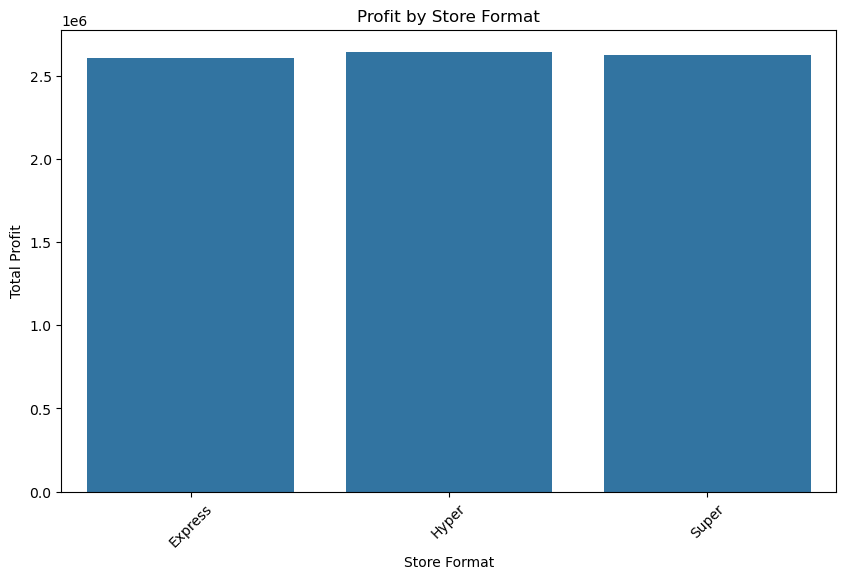

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=store_analysis,
    x="Store_Format",
    y="Total_Profit"
)

plt.title("Profit by Store Format")
plt.xlabel("Store Format")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

In [19]:
channel_analysis = clean_df.groupby("Channel").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

channel_analysis["Profit_Margin_%"] = (
    channel_analysis["Total_Profit"] /
    channel_analysis["Total_Revenue"]
) * 100

channel_analysis

,Channel,Total_Revenue,Total_Profit,Units_Sold,Profit_Margin_%
0,Offline,1.305448e+07,2.609320e+06,99698,19.987919
1,Omnichannel,1.316299e+07,2.637861e+06,100280,20.039982
2,Online,1.311766e+07,2.626505e+06,99851,20.022664


In [21]:
city_analysis = clean_df.groupby("City").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Profit=("Margin", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

city_analysis["Profit_Margin_%"] = (
    city_analysis["Total_Profit"] /
    city_analysis["Total_Revenue"]
) * 100

city_analysis.sort_values(
    by="Total_Profit",
    ascending=False
)

,City,Total_Revenue,Total_Profit,Units_Sold,Profit_Margin_%
5,Kolkata,4.999465e+06,998628.701894,38049,19.974711
3,Delhi,4.985262e+06,997031.982294,37946,19.999590
4,Hyderabad,4.950787e+06,989549.918248,37568,19.987730
7,Pune,4.899357e+06,987116.417330,37018,20.147878
6,Mumbai,4.897600e+06,984144.670001,37273,20.094427
2,Chennai,4.900659e+06,982972.844229,37533,20.057972
0,Ahmedabad,4.877775e+06,971456.681198,37209,19.915981
1,Bengaluru,4.824230e+06,962784.440103,37233,19.957266


In [23]:
top_cities = city_analysis.sort_values(
    by="Total_Revenue",
    ascending=False
).head(10)

top_cities

,City,Total_Revenue,Total_Profit,Units_Sold,Profit_Margin_%
5,Kolkata,4.999465e+06,998628.701894,38049,19.974711
3,Delhi,4.985262e+06,997031.982294,37946,19.999590
4,Hyderabad,4.950787e+06,989549.918248,37568,19.987730
2,Chennai,4.900659e+06,982972.844229,37533,20.057972
7,Pune,4.899357e+06,987116.417330,37018,20.147878
6,Mumbai,4.897600e+06,984144.670001,37273,20.094427
0,Ahmedabad,4.877775e+06,971456.681198,37209,19.915981
1,Bengaluru,4.824230e+06,962784.440103,37233,19.957266


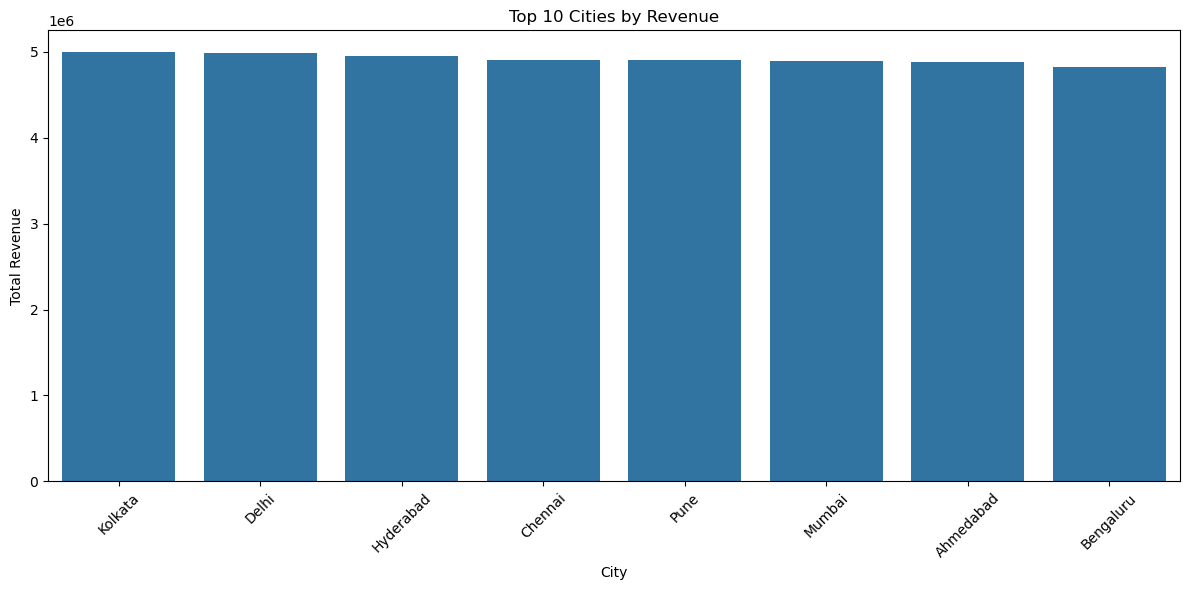

In [25]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_cities,
    x="City",
    y="Total_Revenue"
)

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

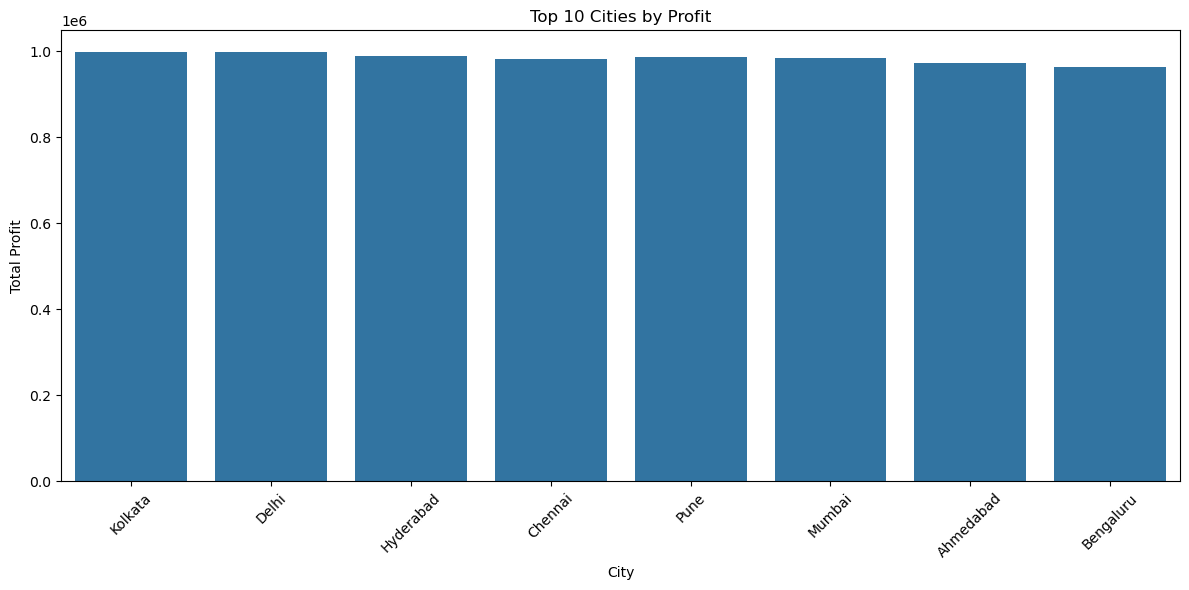

In [27]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_cities,
    x="City",
    y="Total_Profit"
)

plt.title("Top 10 Cities by Profit")
plt.xlabel("City")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
inventory_risk = clean_df.groupby("Category").agg(
    Average_Stock=("Stock_On_Hand", "mean"),
    Average_Reorder_Level=("Reorder_Level", "mean"),
    Total_Units_Sold=("Units", "sum"),
    Total_Profit=("Margin", "sum")
).reset_index()

inventory_risk["Stock_Gap"] = (
    inventory_risk["Average_Stock"] -
    inventory_risk["Average_Reorder_Level"]
)

inventory_risk

,Category,Average_Stock,Average_Reorder_Level,Total_Units_Sold,Total_Profit,Stock_Gap
0,Beverages,274.397775,49.387922,37863,983238.273218,225.009853
1,Dairy,274.192013,49.457539,36770,958654.274803,224.734474
2,Fruits,274.329792,49.428470,38195,993337.256857,224.901322
3,Grocery,273.460683,49.729617,37400,996634.794798,223.731067
4,Home Care,274.317340,49.361045,37790,982373.840734,224.956295
5,Personal Care,275.142477,49.450399,37012,981586.979222,225.692078
6,Snacks,273.907144,49.567764,37418,992112.232178,224.339380
7,Vegetables,273.501684,49.362412,37381,985748.003486,224.139272


In [31]:
inventory_risk.sort_values(
    by="Stock_Gap",
    ascending=True
)

,Category,Average_Stock,Average_Reorder_Level,Total_Units_Sold,Total_Profit,Stock_Gap
3,Grocery,273.460683,49.729617,37400,996634.794798,223.731067
7,Vegetables,273.501684,49.362412,37381,985748.003486,224.139272
6,Snacks,273.907144,49.567764,37418,992112.232178,224.339380
1,Dairy,274.192013,49.457539,36770,958654.274803,224.734474
2,Fruits,274.329792,49.428470,38195,993337.256857,224.901322
4,Home Care,274.317340,49.361045,37790,982373.840734,224.956295
0,Beverages,274.397775,49.387922,37863,983238.273218,225.009853
5,Personal Care,275.142477,49.450399,37012,981586.979222,225.692078


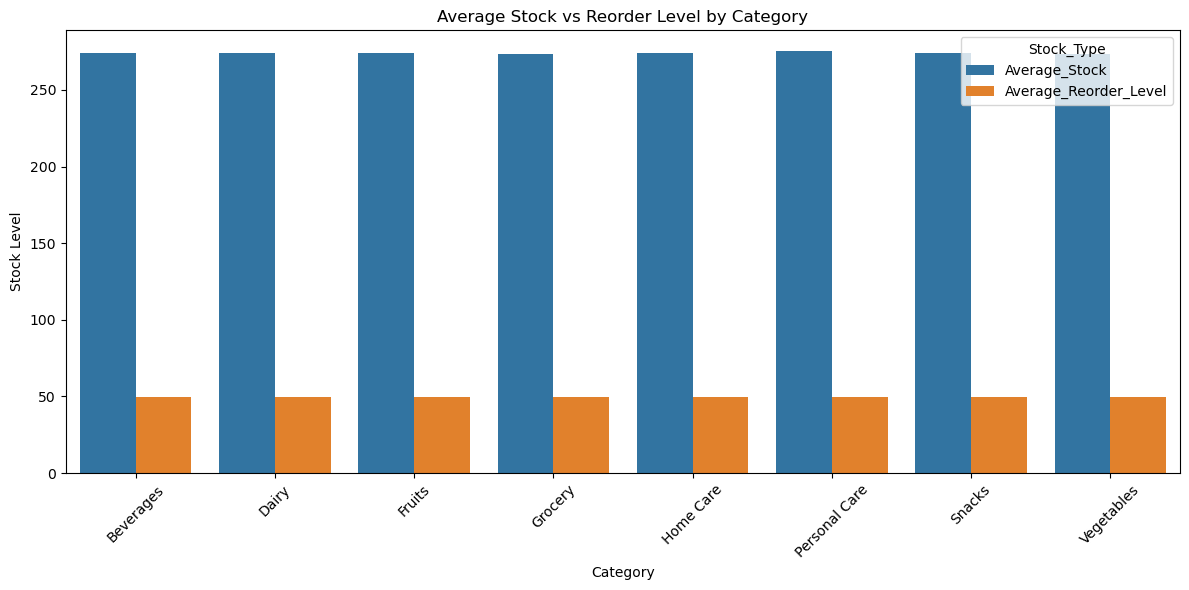

In [33]:
inventory_plot = inventory_risk.melt(
    id_vars="Category",
    value_vars=[
        "Average_Stock",
        "Average_Reorder_Level"
    ],
    var_name="Stock_Type",
    value_name="Stock_Level"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=inventory_plot,
    x="Category",
    y="Stock_Level",
    hue="Stock_Type"
)

plt.title("Average Stock vs Reorder Level by Category")
plt.xlabel("Category")
plt.ylabel("Stock Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
correlation_data = clean_df[
    [
        "Stock_On_Hand",
        "Reorder_Level",
        "Lead_Time_Days",
        "Units",
        "Revenue",
        "Margin"
    ]
].corr()

correlation_data

,Stock_On_Hand,Reorder_Level,Lead_Time_Days,Units,Revenue,Margin
Stock_On_Hand,1.000000,0.003104,-0.004712,-0.000632,-0.002458,-0.000610
Reorder_Level,0.003104,1.000000,0.004139,0.001444,0.001381,0.004191
Lead_Time_Days,-0.004712,0.004139,1.000000,-0.001880,-0.003830,-0.003119
Units,-0.000632,0.001444,-0.001880,1.000000,0.626647,0.501979
Revenue,-0.002458,0.001381,-0.003830,0.626647,1.000000,0.875647
Margin,-0.000610,0.004191,-0.003119,0.501979,0.875647,1.000000


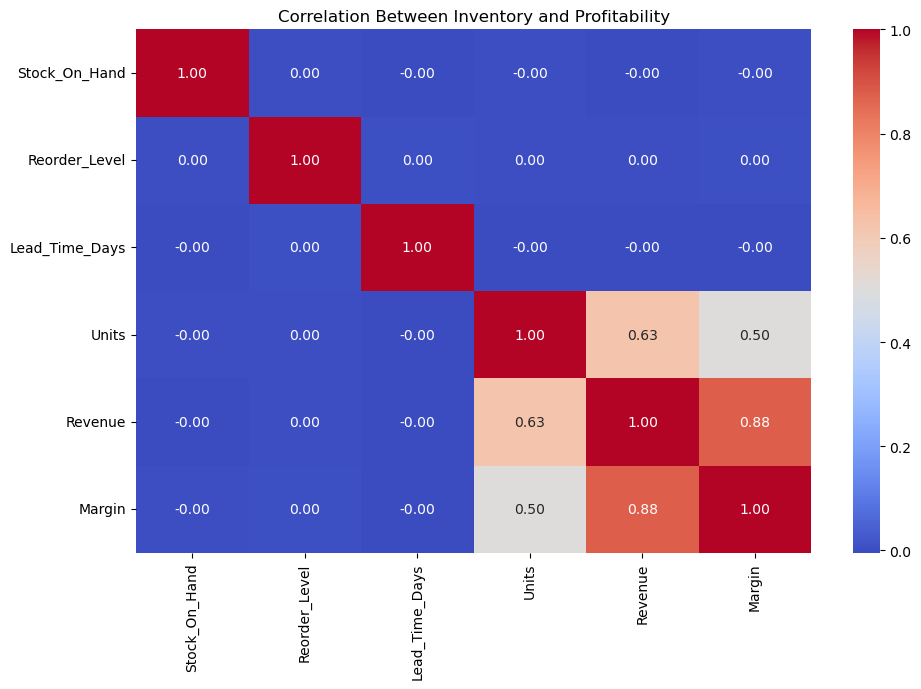

In [37]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Inventory and Profitability")
plt.tight_layout()
plt.show()

In [39]:
lead_time_profit = clean_df.groupby("Lead_Time_Days").agg(
    Total_Profit=("Margin", "sum"),
    Total_Revenue=("Revenue", "sum"),
    Units_Sold=("Units", "sum")
).reset_index()

lead_time_profit.head(10)

,Lead_Time_Days,Total_Profit,Total_Revenue,Units_Sold
0,3,655034.984507,3.279956e+06,25150
1,4,658227.314095,3.298404e+06,24943
2,5,646461.569692,3.223860e+06,24430
3,6,666518.639849,3.305666e+06,24879
4,7,660580.261964,3.295780e+06,24956
5,8,647669.612323,3.255676e+06,25064
6,9,644655.647667,3.227425e+06,24859
7,10,657958.709938,3.278840e+06,25050
8,11,664463.972814,3.301058e+06,25086
9,12,650520.915278,3.257409e+06,24941


In [41]:
clean_df.to_csv(
    "retail_cleaned_data.csv",
    index=False
)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
